In [7]:
import sys
sys.path.append("../src")

import importlib
import re

import pandas as pd
import newGOenrichment as ge

importlib.reload(ge)

files = {
    "Proneural": "../data/processed/new_diff/CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv",
    "Classical": "../data/processed/new_diff/CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv",
    "Mesenchymal": "../data/processed/new_diff/CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv"
}

pathway_genes_df = pd.read_csv(
    "../data/interim/network_stat/complex_pathway_gene_list.csv",
    low_memory=False
)

apoptosis_genes = set(
    pathway_genes_df.loc[
        pathway_genes_df["pathway"].fillna("").str.lower().eq("apoptosis"),
        "gene"
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .tolist()
)

def add_apoptosis_gene_count(go_df, apoptosis_gene_set):
    if go_df.empty:
        out = go_df.copy()
        out["Apoptosis Gene count"] = 0
        return out

    gene_col_candidates = [
        "Genes",
        "genes",
        "geneID",
        "Lead_genes"
    ]

    gene_col = next(
        (col for col in gene_col_candidates if col in go_df.columns),
        None
    )

    if gene_col is None:
        raise ValueError(
            "Could not find a gene-list column. Available columns: "
            + ", ".join(go_df.columns.astype(str))
        )

    out = go_df.copy()

    def split_genes(gene_text):
        if pd.isna(gene_text):
            return []

        return [
            g.strip()
            for g in re.split(r"[;/,]", str(gene_text))
            if g and g.strip()
        ]

    out["Apoptosis Gene count"] = out[gene_col].apply(
        lambda x: len(
            {g.upper() for g in split_genes(x)} & apoptosis_gene_set
        )
    )

    return out


Proneural
Significant genes after filtering: 28184
Genes sent to Enrichr: 4000
Proneural: BP


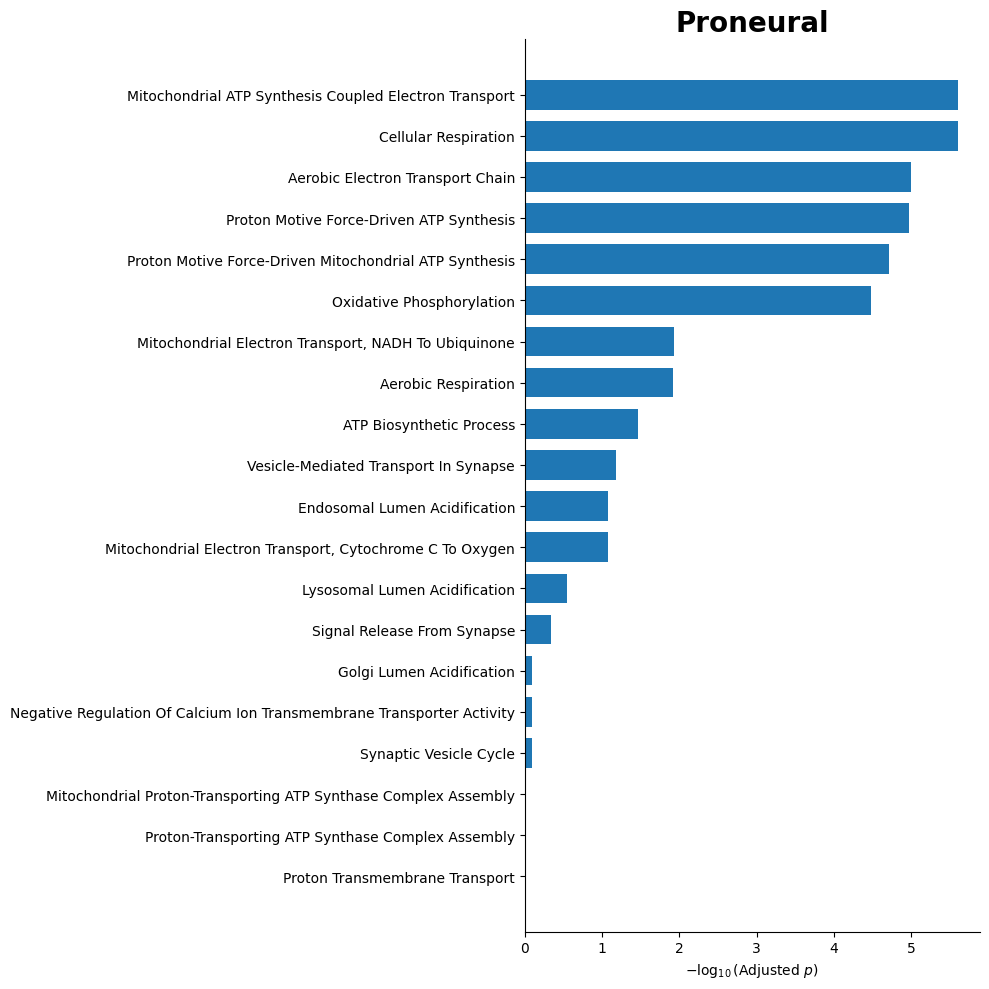


Classical
Significant genes after filtering: 27836
Genes sent to Enrichr: 4000
Classical: BP


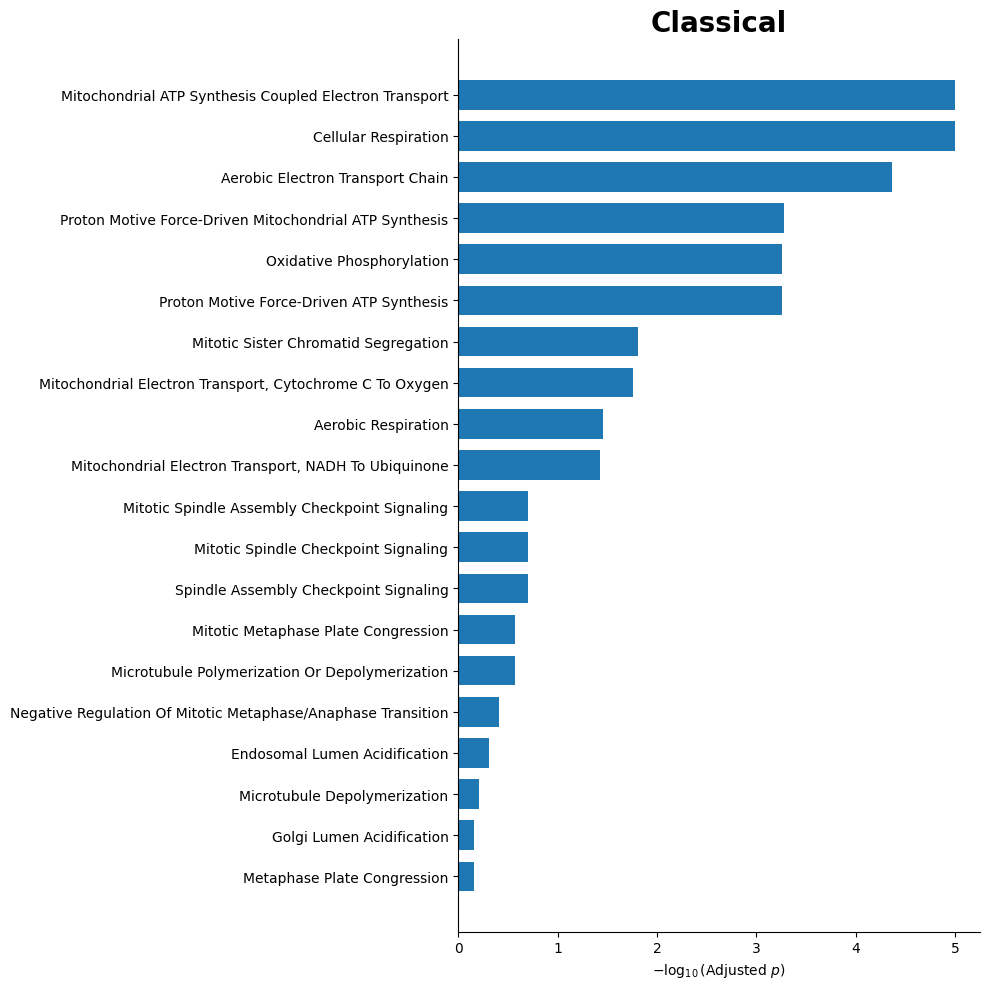


Mesenchymal
Significant genes after filtering: 28317
Genes sent to Enrichr: 4000
Mesenchymal: BP


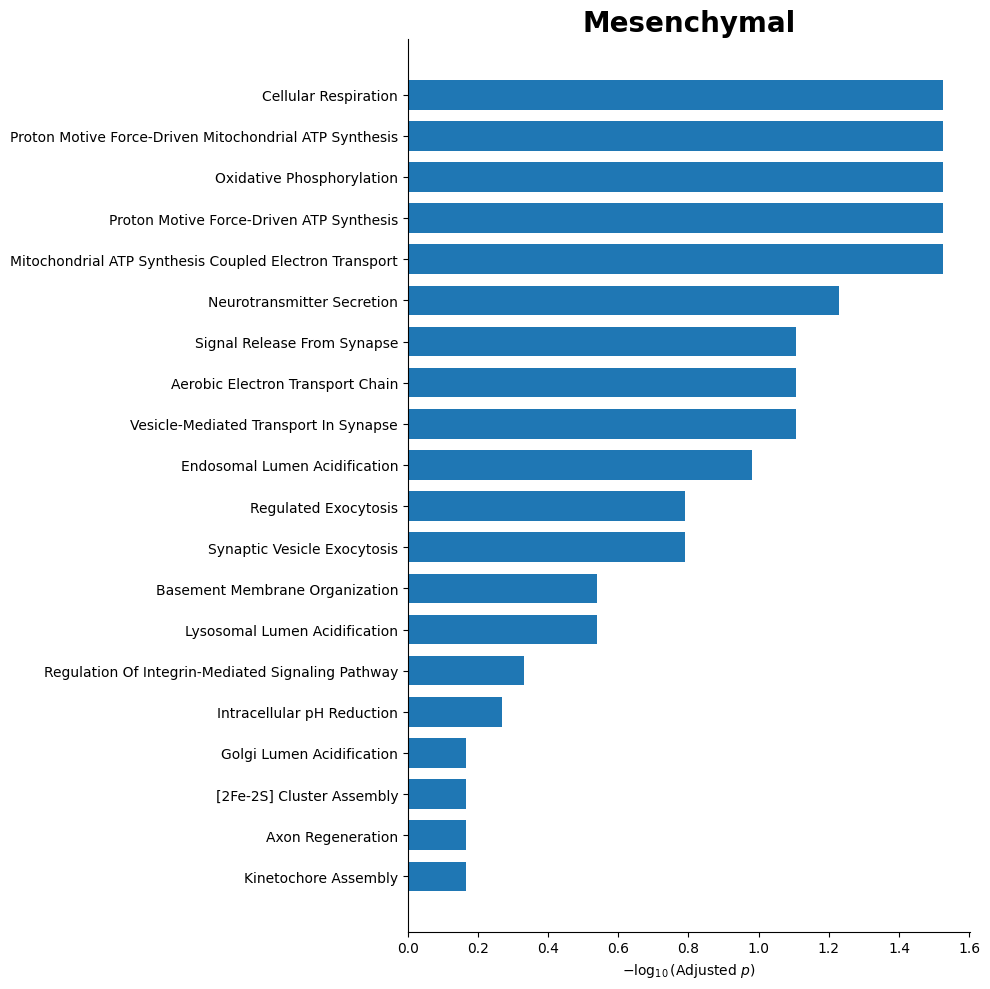

In [8]:
go_combined = {}

for subtype, file in files.items():
    go_combined[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )

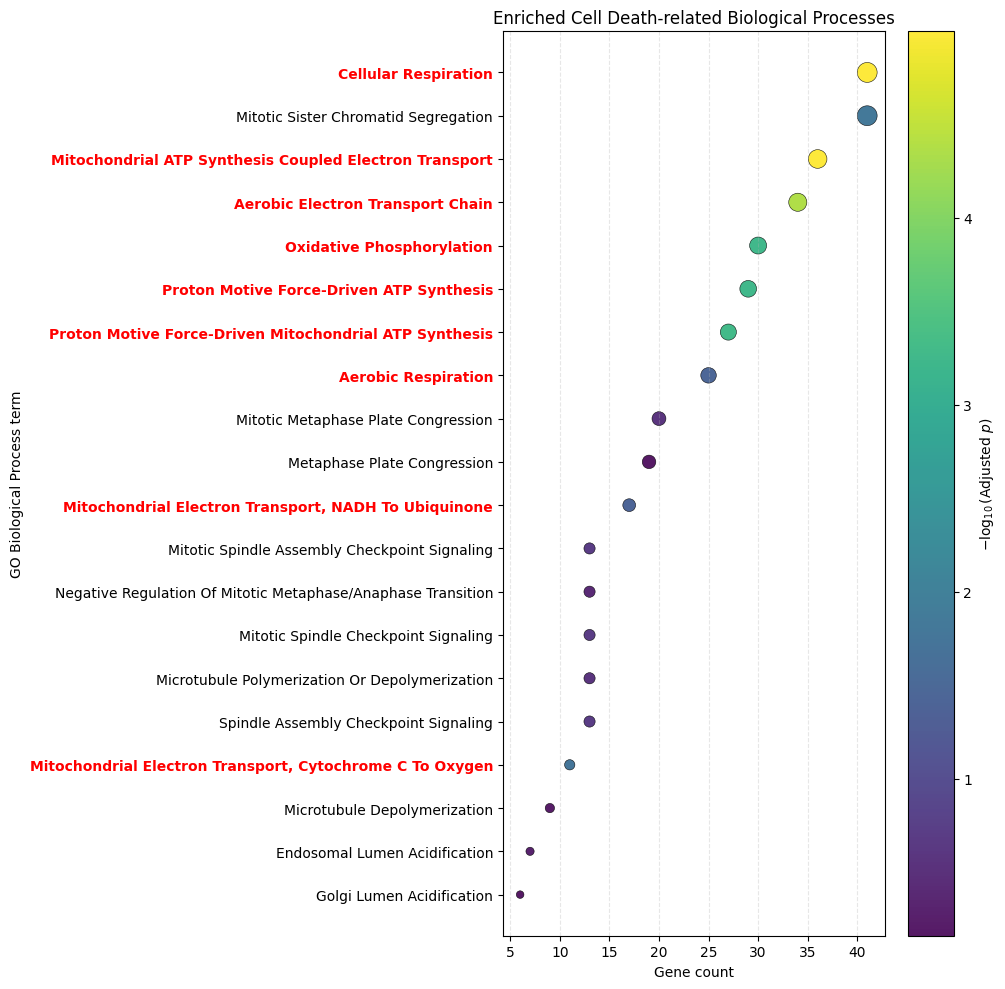

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# ============================================================
# CLASSICAL GO DOT PLOT
# ============================================================

classical_bp = go_combined["Classical"].copy()

if classical_bp.empty:
    print("No Classical GO terms to plot.")

else:

    # --------------------------------------------------------
    # Select top GO terms
    # --------------------------------------------------------

    classical_bp = (
        classical_bp
        .sort_values("Adjusted P-value")
        .head(20)
        .copy()
    )

    # --------------------------------------------------------
    # Clean GO term labels
    # --------------------------------------------------------

    classical_bp["Term_clean"] = (
        classical_bp["Term"]
        .str.replace(
            r"\s*\(GO:\d+\)",
            "",
            regex=True
        )
    )

    # --------------------------------------------------------
    # Gene count
    # --------------------------------------------------------

    if "Count" in classical_bp.columns:

        classical_bp["Gene count"] = pd.to_numeric(
            classical_bp["Count"],
            errors="coerce"
        )

    elif "Overlap" in classical_bp.columns:

        classical_bp["Gene count"] = pd.to_numeric(
            classical_bp["Overlap"]
            .astype(str)
            .str.split("/")
            .str[0],
            errors="coerce"
        )

    else:

        gene_col = next(
            (
                c for c in
                ["Genes", "genes", "geneID", "Lead_genes"]
                if c in classical_bp.columns
            ),
            None
        )

        if gene_col is None:
            raise ValueError(
                "No usable gene count column found."
            )

        classical_bp["Gene count"] = (
            classical_bp[gene_col]
            .fillna("")
            .apply(
                lambda s: len([
                    g for g in re.split(
                        r"[;/,]",
                        str(s)
                    )
                    if g.strip()
                ])
            )
        )

    # --------------------------------------------------------
    # -log10 adjusted p-value
    # --------------------------------------------------------

    classical_bp["neg_log10_adj_p"] = (
        -np.log10(
            classical_bp["Adjusted P-value"]
            .clip(lower=1e-300)
        )
    )

    # --------------------------------------------------------
    # Sort by gene count
    # --------------------------------------------------------

    plot_df = (
        classical_bp
        .sort_values(
            "Gene count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig_height = max(
        6,
        0.4 * len(plot_df) + 2
    )

    fig, ax = plt.subplots(
        figsize=(10, fig_height)
    )

    scatter = ax.scatter(
        plot_df["Gene count"],
        plot_df["Term_clean"],
        s=plot_df["Gene count"] * 5,
        c=plot_df["neg_log10_adj_p"],
        cmap="viridis",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )

    # --------------------------------------------------------
    # GO term labels
    # --------------------------------------------------------

    ax.set_yticks(
        range(len(plot_df))
    )

    ax.set_yticklabels(
        plot_df["Term_clean"]
    )

    # --------------------------------------------------------
    # Highlight OXPHOS-related biological processes
    # --------------------------------------------------------

    oxphos_keywords = [
        "oxidative phosphorylation",
        "respiratory electron transport",
        "electron transport chain",
        "mitochondrial respiratory chain",
        "respiratory chain",
        "mitochondrial electron transport",
        "aerobic respiration",
        "energy derivation by oxidation of organic compounds",
        "proton motive force",
        "ATP synthesis",
        "ATP biosynthetic process",
        "mitochondrial ATP synthesis",
        "cellular respiration",
        "electron transport"
    ]

    for tick, term in zip(
        ax.get_yticklabels(),
        plot_df["Term_clean"]
    ):

        term_lower = term.lower()

        if any(
            keyword in term_lower
            for keyword in oxphos_keywords
        ):

            tick.set_color("red")
            tick.set_fontweight("bold")

        else:

            tick.set_color("black")

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = plt.colorbar(
        scatter,
        ax=ax
    )

    cbar.set_label(
        r"$-\log_{10}(\mathrm{Adjusted}\ p)$"
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "Gene count"
    )

    ax.set_ylabel(
        "GO Biological Process term"
    )

    ax.set_title(
        "Enriched Cell Death-related Biological Processes"
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    # Highest gene count at top
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# FIND APOPTOSIS / CELL-DEATH RELATED GO TERMS
# ============================================================

cell_death_keywords = [
    "apoptosis",
    "apoptotic",
    "cell death",
    "programmed cell death",
    "cell killing",
    "cell suicide",
    "caspase",
    "death receptor",
    "extrinsic apoptotic",
    "intrinsic apoptotic",
    "mitochondrial apoptotic",
    "necrosis",
    "necroptosis",
    "pyroptosis",
    "ferroptosis",
    "autophagy",
]

for subtype, results in go_combined.items():

    print("\n" + "=" * 70)
    print(f"{subtype}")
    print("=" * 70)

    if results.empty:
        print("No enrichment results.")
        continue

    # Search GO terms
    mask = (
        results["Term"]
        .fillna("")
        .str.lower()
        .apply(
            lambda term: any(
                keyword in term
                for keyword in cell_death_keywords
            )
        )
    )

    cell_death_terms = (
        results.loc[mask]
        .sort_values("Adjusted P-value")
        [[
            "Term",
            "Adjusted P-value",
            "Combined Score",
            "Overlap",
            "Genes"
        ]]
    )

    if cell_death_terms.empty:
        print("No apoptosis/cell-death related terms found.")

    else:
        print(
            f"Found {len(cell_death_terms)} "
            "apoptosis/cell-death related terms:\n"
        )

        display(cell_death_terms)


Proneural
Found 114 apoptosis/cell-death related terms:



,Term,Adjusted P-value,Combined Score,Overlap,Genes
39,Regulation Of Autophagy Of Mitochondrion (GO:1...,0.999996,10.960355,8/19,GSK3A;FBXW7;FKBP8;VDAC1;PARK7;DNM1L;SREBF2;CAMKK2
196,Apoptotic Nuclear Changes (GO:0030262),0.999996,2.912693,5/16,TOP2A;DICER1;BLCAP;CDK5RAP3;DEDD2
244,Regulation Of Intrinsic Apoptotic Signaling Pa...,0.999996,2.446998,4/13,TAF9;RPL26;CD44;ZNF385A
300,Regulation Of Macroautophagy (GO:0016241),0.999996,1.546502,22/96,ATP6V1A;SCOC;ATP6V1G2;SNX32;VPS26A;CLN3;UCHL1;...
344,Positive Regulation Of Autophagy Of Mitochondr...,0.999996,1.942260,3/10,PARK7;SLC25A4;CAMKK2
...,...,...,...,...,...
4009,Cellular Response To Tumor Necrosis Factor (GO...,0.999996,0.000016,9/119,IKBKB;BAG4;TRAF6;ILK;HAS2;NR1D1;BRCA1;ADAMTS12...
4010,Regulation Of Apoptotic Process (GO:0042981),0.999996,0.000034,102/705,MTCH1;TNFRSF6B;ARL6IP1;TRRAP;FAIM2;PARK7;USP17...
4019,Negative Regulation Of Apoptotic Process (GO:0...,0.999996,0.000026,64/482,ITGB1;TNFRSF6B;ARL6IP1;HTR2B;KIF14;FAIM2;PARK7...
4036,Response To Tumor Necrosis Factor (GO:0034612),0.999996,0.000007,7/108,IKBKB;BAG4;HAS2;NR1D1;BRCA1;ADAMTS12;MAP2K7



Classical
Found 115 apoptosis/cell-death related terms:



,Term,Adjusted P-value,Combined Score,Overlap,Genes
32,Regulation Of Autophagy Of Mitochondrion (GO:1...,0.845343,1.808623e+01,9/19,GSK3A;PINK1;FZD5;FBXW7;CSNK2A2;FKBP8;VDAC1;DNM...
75,Regulation Of Macroautophagy (GO:0016241),0.999996,5.271516e+00,27/96,ATP6V1A;SCOC;SNX32;VPS26A;CLN3;UCHL1;MAPK8;CAP...
278,Macroautophagy (GO:0016236),0.999996,2.171201e+00,25/104,ILRUN;STX17;VPS4A;GABARAP;STK3;CLN3;ZFYVE26;MA...
604,Regulation Of Tumor Necrosis Factor-Mediated S...,0.999996,1.213637e+00,11/48,IKBKB;PPP2CB;PELI3;CARD8;SPPL2A;H2BC11;OTULIN;...
635,Programmed Necrotic Cell Death (GO:0097300),0.999996,1.441518e+00,3/11,ITPK1;TRPM7;DNM1L
...,...,...,...,...,...
4124,Cellular Response To Tumor Necrosis Factor (GO...,0.999996,1.806146e-04,11/119,IKBKB;RRAGA;BAG4;TRAF6;ILK;HAS2;PTK2B;NR1D1;BR...
4129,Positive Regulation Of Tumor Necrosis Factor S...,0.999996,1.235489e-04,6/82,C1QTNF4;MAVS;FZD5;DDT;STAT3;TMEM106A
4181,Regulation Of Apoptotic Process (GO:0042981),0.999996,4.963740e-05,103/705,MTCH1;TNFRSF6B;ARL6IP1;TRRAP;FAIM2;USP17L7;HMG...
4226,Regulation Of Tumor Necrosis Factor Production...,0.999996,5.218887e-06,9/127,ILRUN;C1QTNF4;MAVS;FZD5;DDT;STAT3;CIDEA;GHRL;T...



Mesenchymal
Found 126 apoptosis/cell-death related terms:



,Term,Adjusted P-value,Combined Score,Overlap,Genes
27,Regulation Of Autophagy Of Mitochondrion (GO:1...,0.999996,18.086232,9/19,GSK3A;PINK1;FZD5;FBXW7;FKBP8;PARK7;DNM1L;SREBF...
35,Regulation Of Tumor Necrosis Factor-Mediated S...,0.999996,10.298607,17/48,SYK;PELI3;CARD8;SPPL2A;GPS2;SPATA2;IKBKB;CASP8...
126,Positive Regulation Of Intrinsic Apoptotic Sig...,0.999996,17.105266,3/5,UBB;MYC;RPL26
263,Regulation Of Macroautophagy (GO:0016241),0.999996,2.658958,24/96,ATP6V1A;SCOC;ATP6V1G2;SNX32;VPS26A;CLN3;UCHL1;...
280,Positive Regulation Of Myeloid Cell Apoptotic ...,0.999996,5.734556,3/7,MEF2C;ANXA1;PIK3CB
...,...,...,...,...,...
4036,Regulation Of Apoptotic Process (GO:0042981),0.999996,0.011519,119/705,MTCH1;ARL6IP1;TRRAP;FAIM2;PARK7;HMGN5;MYC;CLEC...
4078,Negative Regulation Of Epithelial Cell Apoptot...,0.999996,0.003875,3/38,PDPK1;SERPINE1;KRIT1
4090,Negative Regulation Of Autophagy (GO:0010507),0.999996,0.004548,6/61,RUBCN;PINK1;IL10RA;STAT3;PTPN22;SNCA
4173,Negative Regulation Of Apoptotic Process (GO:0...,0.999996,0.005067,76/482,ITGB1;ARL6IP1;HTR2B;KIF14;FAIM2;PARK7;PTMS;RNF...


In [11]:
import pandas as pd
import os

# ============================================================
# PATHS
# ============================================================

base_oxphos = "../data/processed/new_oxphos"
base_pathway = "../data/processed/new_pathway_diff"


# ============================================================
# SUBTYPES
# ============================================================

subtypes = [
    "classical",
    "proneural",
    "mesenchymal"
]


# ============================================================
# CELL-DEATH PATHWAYS
# ============================================================

cell_death_pathways = [
    "Apoptosis",
    "Ferroptosis",
    "Necroptosis",
    "Pyroptosis",
    "Autophagy"
]


# ============================================================
# PROCESS EACH SUBTYPE
# ============================================================

for subtype in subtypes:

    print("\n" + "=" * 70)
    print(f"PROCESSING {subtype.upper()}")
    print("=" * 70)


    # ========================================================
    # COMPLEX FILES
    # ========================================================

    complex_files = {
        "Complex I":
            f"{base_oxphos}/{subtype}_complex_i.csv",

        "Complex II":
            f"{base_oxphos}/{subtype}_complex_ii.csv",

        "Complex III":
            f"{base_oxphos}/{subtype}_complex_iii.csv",

        "Complex IV":
            f"{base_oxphos}/{subtype}_complex_iv.csv",

        "Complex V":
            f"{base_oxphos}/{subtype}_complex_v.csv",
    }


    # ========================================================
    # STORE ALL GENES
    # ========================================================

    all_genes = []


    # ========================================================
    # LOAD OXPHOS COMPLEX GENES
    # ========================================================

    print("\n--- OXPHOS complexes ---")

    for complex_name, filepath in complex_files.items():

        if not os.path.exists(filepath):
            print(
                f"WARNING: {filepath} not found"
            )
            continue

        df = pd.read_csv(
            filepath
        )

        print(
            f"{complex_name}: {len(df)} rows"
        )

        gene_col = next(
            (
                col for col in
                [
                    "gene_name",
                    "gene",
                    "Gene",
                    "symbol",
                    "Symbol"
                ]
                if col in df.columns
            ),
            None
        )

        if gene_col is None:
            raise ValueError(
                f"No gene column found in {complex_name}.\n"
                f"Available columns: {list(df.columns)}"
            )

        genes = (
            df[gene_col]
            .dropna()
            .astype(str)
            .str.strip()
            .str.upper()
            .tolist()
        )

        all_genes.extend(
            genes
        )


    # ========================================================
    # LOAD CELL-DEATH PATHWAY GENES
    # ========================================================

    print("\n--- Cell-death pathways ---")

    for pathway in cell_death_pathways:

        pathway_file = (
            f"{base_pathway}/{subtype}/"
            f"{subtype}_{pathway}_diff.csv"
        )

        if not os.path.exists(pathway_file):
            print(
                f"WARNING: {pathway_file} not found"
            )
            continue

        df = pd.read_csv(
            pathway_file
        )

        print(
            f"{pathway}: {len(df)} rows"
        )

        gene_col = next(
            (
                col for col in
                [
                    "gene_name",
                    "gene",
                    "Gene",
                    "symbol",
                    "Symbol"
                ]
                if col in df.columns
            ),
            None
        )

        if gene_col is None:
            raise ValueError(
                f"No gene column found in "
                f"{pathway} file.\n"
                f"Available columns: {list(df.columns)}"
            )

        genes = (
            df[gene_col]
            .dropna()
            .astype(str)
            .str.strip()
            .str.upper()
            .tolist()
        )

        all_genes.extend(
            genes
        )


    # ========================================================
    # REMOVE EMPTY / NAN / DUPLICATES
    # ========================================================

    string_genes = sorted(
        set(
            gene
            for gene in all_genes
            if gene
            and gene != "NAN"
            and gene != "NONE"
        )
    )


    # ========================================================
    # SUMMARY
    # ========================================================

    print("\n" + "-" * 70)
    print(
        f"{subtype.upper()} FINAL STRING GENE LIST"
    )
    print("-" * 70)

    print(
        "Total genes before deduplication:",
        len(all_genes)
    )

    print(
        "Unique genes:",
        len(string_genes)
    )


    # ========================================================
    # SAVE
    # ========================================================

    output_file = (
        f"{base_pathway}/"
        f"{subtype}_complexes_all_cell_death_STRING_genes.csv"
    )

    pd.DataFrame({
        "gene": string_genes
    }).to_csv(
        output_file,
        index=False
    )

    print(
        "\nSaved:"
    )

    print(
        output_file
    )


PROCESSING CLASSICAL

--- OXPHOS complexes ---
Complex I: 143 rows
Complex II: 24 rows
Complex III: 16 rows
Complex IV: 52 rows
Complex V: 26 rows

--- Cell-death pathways ---
Apoptosis: 105 rows
Ferroptosis: 31 rows
Necroptosis: 114 rows
Pyroptosis: 19 rows
Autophagy: 101 rows

----------------------------------------------------------------------
CLASSICAL FINAL STRING GENE LIST
----------------------------------------------------------------------
Total genes before deduplication: 631
Unique genes: 470

Saved:
../data/processed/new_pathway_diff/classical_complexes_all_cell_death_STRING_genes.csv

PROCESSING PRONEURAL

--- OXPHOS complexes ---
Complex I: 143 rows
Complex II: 24 rows
Complex III: 16 rows
Complex IV: 52 rows
Complex V: 26 rows

--- Cell-death pathways ---
Apoptosis: 102 rows
Ferroptosis: 30 rows
Necroptosis: 113 rows
Pyroptosis: 19 rows
Autophagy: 93 rows

----------------------------------------------------------------------
PRONEURAL FINAL STRING GENE LIST
---------